# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402108
- 姓名：吴以凡
- GitHub 仓库链接：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-yijinfengren-create
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

**学生信息**：032402108 吴以凡  
**数据文件**：`ershoufang_list.csv`  

本报告基于福州市二手房房源数据，围绕房源分布、价格水平、面积和户型结构、房龄与楼层特征等方面进行分析。报告重点不是直接使用 CSV 中已经整理好的数值字段，而是优先从原始文本字段中提取可分析变量，并说明缺失值、重复值和极端值的处理依据。

## 1. 摘要

本报告对 `ershoufang_list.csv` 中的福州二手房挂牌数据进行清洗、统计分析和可视化。数据共包含 11856 条房源记录，字段涉及市区、标题、户型、面积、楼层、建造时间、小区、总价、均价和房龄等信息。报告优先从 `面积`、`总价`、`均价`、`时间`、`楼层`、`户型` 等原始文本字段中提取数值变量，再进行统计分析和图表展示。

主要方法包括：

- 从带单位或混合格式的文本中提取面积、总价、均价、建造年份、总楼层、室、厅、卫等变量。
- 检查缺失值、重复值、近似重复、格式问题和价格/面积极端值，并说明处理依据。
- 使用 `pandas` 和 `numpy` 完成分组统计、排序筛选、交叉分析和相关性分析。
- 使用 `matplotlib`、`seaborn` 和 `plotly` 绘制静态图和交互式图表。

主要结论包括：

- 房源供应主要集中在晋安区和仓山区；价格非缺失样本中，晋安区有 4346 条，仓山区有 3926 条。
- 不同区域价格差异明显。鼓楼区均价中位数约 22973 元/平方米，罗源县约 5103 元/平方米，体现出中心城区与外围县市之间的价格梯度。
- 3 室房源是样本中的主流户型，共 7183 条，中位总价约 175 万元，符合家庭型居住需求。
- 面积与总价存在较明显正相关，但面积与均价相关性较弱，说明单价更多受到区位、板块、小区品质、房龄等因素影响。
- 高总价、高均价和大面积房源多属于豪宅、别墅或改善型房源，是福州二手房市场中的真实高端样本，不应简单删除。
- 总价和均价缺失的 26 条样本不做填充，只在价格相关分析中排除；非价格分析仍保留这些记录。

## 2. 数据读取与分析目标

本数据是福州市二手房挂牌房源信息，每一行代表一条房源记录。主要字段含义如下：

| 字段 | 大致含义 | 后续用途 |
|---|---|---|
| `id`、`房源链接` | 房源编号和网页链接 | 用于识别记录和检查重复 |
| `城市`、`市区`、`所属区域` | 房源所在城市、市区和更具体板块/地址 | 分析区域供应量和价格差异 |
| `标题` | 房源营销标题 | 提取“地铁、电梯、精装、学区”等关键词 |
| `户型` | 几室几厅几卫 | 提取室、厅、卫，分析户型结构和价格关系 |
| `面积`、`面积数值` | 房屋面积文本和已整理数值 | 从文本重新提取面积，并与现成数值核对 |
| `方位`、`楼层` | 朝向和楼层信息 | 分析居住属性，提取楼层类型和总楼层 |
| `时间`、`房龄` | 建造年份文本和房龄分类 | 提取建造年份，估算房龄，分析房龄与价格关系 |
| `所属小区` | 小区名称 | 分析样本较多小区的价格水平 |
| `总价`、`均价` | 挂牌总价和单位面积价格 | 核心价格变量，分析价格分布和影响因素 |

本报告计划围绕以下问题展开：

1. 福州二手房房源主要集中在哪些市区和板块？
2. 不同市区、户型、房龄的总价和均价有什么差异？
3. 面积、户型、楼层、房龄等变量与价格之间有什么关系？
4. 标题中提到地铁、电梯、精装、学区等卖点的房源，价格是否存在差异？
5. 数据中的缺失值、近似重复和高价/大面积极端值应如何结合实际含义处理？

In [1]:
# 导入常用数据分析与可视化库
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from IPython.display import display, Markdown
from matplotlib import font_manager

warnings.filterwarnings("ignore")

# 中文显示设置：先设置 seaborn 主题，再覆盖 matplotlib 字体配置，避免中文坐标轴显示为空白。
font_candidates = ["Microsoft YaHei", "SimHei", "SimSun", "KaiTi", "Arial Unicode MS", "DejaVu Sans"]
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
chosen_font = next((f for f in font_candidates if f in available_fonts), "DejaVu Sans")
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = [chosen_font] + font_candidates
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False
pio.renderers.default = "notebook_connected"

DATA_PATH = Path("ershoufang_list.csv")
ANALYSIS_YEAR = 2026

print("当前工作目录：", Path.cwd())
print("数据文件是否存在：", DATA_PATH.exists())
print("Matplotlib 中文字体：", chosen_font)

当前工作目录： d:\Desktop\我的课程\数据分析可视化\期末考\正式考试
数据文件是否存在： True
Matplotlib 中文字体： Microsoft YaHei


In [2]:
# 读取数据。如果出现编码问题，可以尝试 encoding='utf-8-sig'
df_raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print(f"数据规模：{df_raw.shape[0]} 行，{df_raw.shape[1]} 列")
print("字段列表：")
print(df_raw.columns.tolist())

数据规模：11856 行，18 列
字段列表：
['id', '城市', '市区', '标题', '户型', '面积', '面积数值', '方位', '楼层', '时间', '所属小区', '所属区域', '房源链接', '总价', '总价数值', '均价', '均价数值', '房龄']


## 3. 数据基本情况

从字段看，数据同时包含原始文本字段和部分已整理的数值字段。例如 `面积` 是带有 `㎡` 单位的文本，`面积数值` 是已经提取好的数值。为了体现数据清洗能力，后续分析优先从 `面积`、`总价`、`均价` 等原始文本字段重新提取数值，再与已有数值列进行核对。

In [3]:
# 查看前 5 行样例数据，确认字段读取正常。
display(df_raw.head())

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


In [4]:
# 数据规模、字段类型和缺失情况
info_df = pd.DataFrame({
    "字段": df_raw.columns,
    "数据类型": df_raw.dtypes.astype(str).values,
    "非空数量": df_raw.notna().sum().values,
    "缺失数量": df_raw.isna().sum().values,
    "缺失比例(%)": (df_raw.isna().mean().values * 100).round(2),
})
display(info_df)

,字段,数据类型,非空数量,缺失数量,缺失比例(%)
0,id,int64,11856,0,0.00
1,城市,object,11856,0,0.00
2,市区,object,11856,0,0.00
3,标题,object,11856,0,0.00
4,户型,object,11856,0,0.00
5,面积,object,11856,0,0.00
6,面积数值,float64,11856,0,0.00
7,方位,object,11856,0,0.00
8,楼层,object,11856,0,0.00
9,时间,object,11856,0,0.00


In [5]:
# 查看文本字段样例，观察单位、空格、混合格式等清洗需求。
# 用 DataFrame 展示，避免 print 输出过长、不整齐。
sample_cols = ["户型", "方位", "楼层", "所属区域", "房龄"]
max_examples = 5

sample_dict = {}
for col in sample_cols:
    values = df_raw[col].dropna().astype(str).drop_duplicates().head(max_examples).tolist()
    values = values + [""] * (max_examples - len(values))
    sample_dict[col] = values

text_sample_df = pd.DataFrame(sample_dict, index=[f"样例{i}" for i in range(1, max_examples + 1)])
display(text_sample_df)

,户型,方位,楼层,所属区域,房龄
样例1,3 室 2 厅 2 卫,南北,中层(共31层),台江 万宝 交通西路,2年内
样例2,3 室 2 厅 1 卫,南,低层(共18层),晋安 五四北 坂中路,2-5年
样例3,2 室 1 厅 1 卫,北,高层(共33层),晋安 福马路 七贤路2号,5-10年
样例4,2 室 2 厅 1 卫,东南,低层(共7层),鼓楼 东街 湖头街,10年以上
样例5,4 室 2 厅 2 卫,西南,高层(共18层),晋安 王庄 连洋西路,


In [6]:
# 原始数值列的描述性统计，仅用于初步理解和后续清洗核对。
display(df_raw[["面积数值", "总价数值", "均价数值"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T.round(2))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
面积数值,11856.0,97.89,25.92,18.0,44.0,60.00,84.73,93.0,113.01,136.0,179.00,500.0
总价数值,11830.0,190.76,111.17,16.8,45.0,79.00,130.00,173.0,225.00,350.0,547.10,3180.0
均价数值,11830.0,19235.60,6925.95,2169.0,5264.0,9512.45,15298.25,18325.5,22268.50,31823.4,41388.68,92968.0


### 数据基本情况小结

根据上述结果，可以对数据形成以下初步理解：

1. **样本规模较大，字段较完整**：数据共有 11856 条房源、18 个字段，能够支持按市区、户型、面积、价格、房龄等维度展开分析。
2. **字段类型以文本为主，存在明显清洗需求**：`面积` 带有 `㎡` 单位，`总价` 带有 `万` 单位，`均价` 带有 `元/㎡` 单位，`户型` 是“几室几厅几卫”的混合文本，`楼层` 是“低层/中层/高层 + 总楼层”的混合格式。因此后续需要先从原始文本中提取数值变量，再进行统计和可视化。
3. **价格字段存在少量缺失**：`总价`、`总价数值`、`均价`、`均价数值` 各缺失 26 条，缺失比例约 0.22%，比例很低。由于价格是核心变量，本报告不会用均值填充，而是在价格相关分析中排除这些缺失记录。
4. **面积和价格分布存在右偏**：面积中位数为 93 平方米，99% 分位数为 179 平方米，但最大值达到 500 平方米；总价中位数为 173 万元，99% 分位数为 547.10 万元，最大值达到 3180 万元；均价中位数为 18325.5 元/平方米，最大值达到 92968 元/平方米。这说明普通住宅是主体，但数据中也包含少量别墅、豪宅或核心区高价房源。
5. **户型和房龄结构较清晰**：户型样例以 2-4 室为主，尤其适合分析家庭型住宅；房龄分为 `2年内`、`2-5年`、`5-10年`、`10年以上`，可以用于比较新房源和老房源的价格差异。

因此，后续分析会同时保留全量样本和主流住宅样本：全量样本反映福州二手房市场的完整结构，主流住宅样本用于观察普通购房者更常见的价格和户型特征。

## 4. 数据质量检查

本部分检查缺失值、重复值、格式问题和极端值。二手房数据中，高总价、高均价、大面积并不一定是错误，可能代表别墅、豪宅或核心区改善型房源。因此本报告会先识别，再结合房源标题、户型、区域等字段判断是否处理。

In [7]:
# 缺失值检查
missing_summary = pd.DataFrame({
    "缺失数量": df_raw.isna().sum(),
    "缺失比例(%)": (df_raw.isna().mean() * 100).round(2),
}).sort_values("缺失数量", ascending=False)
display(missing_summary)

print("存在总价缺失的样本数量：", df_raw["总价"].isna().sum())
print("存在均价缺失的样本数量：", df_raw["均价"].isna().sum())
display(df_raw[df_raw["总价"].isna()].head(5))

,缺失数量,缺失比例(%)
均价,26,0.22
总价数值,26,0.22
均价数值,26,0.22
总价,26,0.22
城市,0,0.00
id,0,0.00
市区,0,0.00
标题,0,0.00
户型,0,0.00
面积,0,0.00


存在总价缺失的样本数量： 26
存在均价缺失的样本数量： 26


,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
52,53,fuzhou,晋安,绿城美的桂语映月 双卫格局 精装修 临地铁 出行方便,3 室 2 厅 2 卫,117㎡,117.00,南北,低层(共16层),2024年建造,绿城美的桂语映月,晋安 王庄 连江西路,https://fz.anjuke.com/prop/view/S4579711867444...,NaN,NaN,NaN,NaN,2年内
67,68,fuzhou,仓山,金山大道 精装可拎包入住 双卫生间 近地铁 次新小区 小三居,3 室 2 厅 2 卫,91.72㎡,91.72,北,高层(共24层),2025年建造,万科城市之光,仓山 金山大道 妙高路,https://fz.anjuke.com/prop/view/S4581445062962...,NaN,NaN,NaN,NaN,2年内
166,167,fuzhou,仓山,万科城市之光 电梯房 朝南 次新小区 楼层好 精装修,4 室 2 厅 2 卫,119㎡,119.00,南,中层(共24层),2025年建造,万科城市之光,仓山 金山大道 妙高路,https://fz.anjuke.com/prop/view/S4383121484569...,NaN,NaN,NaN,NaN,2年内
242,243,fuzhou,仓山,万科城市之光高层精装家电家具齐全拎包入住,3 室 2 厅 2 卫,92㎡,92.00,南北,高层(共24层),2025年建造,万科城市之光,仓山 金山大道 妙高路,https://fz.anjuke.com/prop/view/S3896119963459...,NaN,NaN,NaN,NaN,2年内
251,252,fuzhou,仓山,万科城市之光 双卫 有电梯 南北通透 商品房 近地铁,4 室 2 厅 2 卫,120㎡,120.00,南北,高层(共24层),2024年建造,万科城市之光,仓山 金山大道 妙高路,https://fz.anjuke.com/prop/view/S3861885468371...,NaN,NaN,NaN,NaN,2年内


In [8]:
# 重复值检查：完全重复、链接重复和关键字段近似重复分别检查。
complete_dup = df_raw.duplicated().sum()
link_dup = df_raw.duplicated(subset=["房源链接"]).sum()
key_cols = ["标题", "户型", "面积", "所属小区", "所属区域", "总价", "均价"]
key_dup = df_raw.duplicated(subset=key_cols).sum()

duplicate_summary = pd.DataFrame({
    "检查类型": ["完全重复行", "房源链接重复", "关键字段近似重复"],
    "重复数量": [complete_dup, link_dup, key_dup],
    "处理方式": [
        "若存在则删除；当前检查为 0",
        "若存在通常代表同一链接重复抓取；当前检查为 0",
        "只用于提示，不直接删除，因为可能是同小区相似房源或房龄分类差异",
    ],
})
display(duplicate_summary)

,检查类型,重复数量,处理方式
0,完全重复行,0,若存在则删除；当前检查为 0
1,房源链接重复,0,若存在通常代表同一链接重复抓取；当前检查为 0
2,关键字段近似重复,1655,只用于提示，不直接删除，因为可能是同小区相似房源或房龄分类差异


### 数据质量检查小结

从数据质量检查结果看，本数据整体可用，但仍存在三类需要说明的问题：

1. **缺失值集中在价格字段**：`总价`、`总价数值`、`均价`、`均价数值` 各有 26 条缺失。由于价格是核心分析变量，不能用均值或中位数随意填充，否则会改变福州二手房价格分布。因此本报告保留这些房源，但在涉及总价、均价、价格相关性和价格图表时，仅使用价格非缺失样本。
2. **没有完全重复行和链接重复**：完全重复行为 0，房源链接重复为 0，说明没有明显的整行重复抓取或同链接重复记录。
3. **关键字段近似重复为 1655 条**：这些记录在标题、户型、面积、小区、区域、总价和均价等字段上相同或高度相似，但不能直接等同于错误数据。二手房平台中可能存在同小区相似户型、同一楼盘多套相近房源，或同一房源因房龄分类、标题营销描述等信息产生近似重复。因此本报告不机械删除这些近似重复记录，而是在结论中将其作为平台房源数据的特点说明。

综上，本报告的数据质量处理原则是：明显重复才删除；价格缺失不填充；极端值和近似重复先结合业务含义判断，不做简单粗暴删除。

## 5. 数据清洗与字段转换

清洗原则：

- **优先从文本字段提取数值**：例如从 `103㎡` 提取面积，从 `199万` 提取总价，从 `19321元/㎡` 提取均价。
- **缺失价格不填充**：总价和均价缺失的 26 条样本不参与价格分析，但仍保留用于区域、户型、楼层等非价格分析。
- **极端值不机械删除**：面积 500㎡、总价 3180 万、高均价 9 万元/㎡以上等房源经标题和户型核查，多数属于别墅或豪宅，是真实市场现象。
- **普通住宅分析另设子集**：为避免豪宅/别墅对均值和散点图视觉效果影响过大，除全量数据外，单独构造一个“主流住宅样本”用于部分图表。

In [9]:
# 建议先复制一份数据，避免直接破坏原始数据
data = df_raw.copy()

# 文本字段去除首尾空格，并压缩连续空白字符。
text_cols = data.select_dtypes(include="object").columns
for col in text_cols:
    data[col] = (
        data[col]
        .astype("string")
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

def extract_number(series):
    # 从带单位文本中提取第一个数字，提取失败返回 NaN。
    return pd.to_numeric(series.astype("string").str.extract(r"(\d+(?:\.\d+)?)", expand=False), errors="coerce")

# 从原始文本字段提取数值变量。
data["面积_㎡"] = extract_number(data["面积"])
data["总价_万元"] = extract_number(data["总价"])
data["均价_元每㎡"] = extract_number(data["均价"])
data["建造年份"] = pd.to_numeric(data["时间"].astype("string").str.extract(r"(\d{4})", expand=False), errors="coerce")
data["估算房龄"] = (ANALYSIS_YEAR - data["建造年份"]).clip(lower=0)

# 楼层字段：提取楼层类型和总楼层。
data["楼层类型"] = data["楼层"].astype("string").str.extract(r"(低层|中层|高层)", expand=False)
data.loc[data["楼层"].astype("string").str.contains(r"共1层", na=False), "楼层类型"] = "独栋/低密"
data["楼层类型"] = data["楼层类型"].fillna("未标明")
data["总楼层"] = pd.to_numeric(data["楼层"].astype("string").str.extract(r"共(\d+)层", expand=False), errors="coerce")

# 户型字段：提取室、厅、卫。
layout_parts = data["户型"].astype("string").str.extract(r"(\d+)\s*室\s*(\d+)\s*厅\s*(\d+)\s*卫")
data["室"] = pd.to_numeric(layout_parts[0], errors="coerce")
data["厅"] = pd.to_numeric(layout_parts[1], errors="coerce")
data["卫"] = pd.to_numeric(layout_parts[2], errors="coerce")
data["户型类别"] = pd.cut(
    data["室"],
    bins=[0, 1, 2, 3, 4, np.inf],
    labels=["1室", "2室", "3室", "4室", "5室及以上"],
    right=True,
)

# 所属区域一般形如“市区 板块 道路”，拆分出板块/商圈。
region_split = data["所属区域"].astype("string").str.split(" ", expand=True)
data["区域_市区"] = region_split[0]
data["板块"] = region_split[1].fillna("未标明")
data["道路或地址"] = region_split.iloc[:, 2:].apply(lambda row: " ".join([x for x in row.dropna().astype(str) if x]), axis=1)
data["道路或地址"] = data["道路或地址"].replace("", "未标明")

# 标题关键词，便于分析一些常见卖点与价格关系。
keyword_patterns = {
    "含地铁": r"地铁|轨道",
    "含电梯": r"电梯",
    "含精装": r"精装|装修好|拎包",
    "含南北通透": r"南北通透|南北",
    "含学区": r"学区|学校|实验|附小|一中|十八中",
}
for new_col, pattern in keyword_patterns.items():
    data[new_col] = data["标题"].astype("string").str.contains(pattern, regex=True, na=False)

# 核对从文本提取出的数值与原表已有数值列是否一致。
check_df = pd.DataFrame({
    "面积提取差异最大值": [(data["面积_㎡"] - data["面积数值"]).abs().max()],
    "总价提取差异最大值": [(data["总价_万元"] - data["总价数值"]).abs().max()],
    "均价提取差异最大值": [(data["均价_元每㎡"] - data["均价数值"]).abs().max()],
})
display(check_df)

display(data[["市区", "户型", "室", "厅", "卫", "户型类别", "面积", "面积_㎡", "总价", "总价_万元", "均价", "均价_元每㎡", "楼层", "楼层类型", "总楼层", "时间", "建造年份", "估算房龄", "板块"]].head())

,面积提取差异最大值,总价提取差异最大值,均价提取差异最大值
0,0.0,0.0,0.0


,市区,户型,室,厅,卫,户型类别,面积,面积_㎡,总价,总价_万元,均价,均价_元每㎡,楼层,楼层类型,总楼层,时间,建造年份,估算房龄,板块
0,台江,3 室 2 厅 2 卫,3,2,2,3室,103㎡,103.0,199万,199.0,19321元/㎡,19321,中层(共31层),中层,31,2025年建造,2025,1,万宝
1,晋安,3 室 2 厅 2 卫,3,2,2,3室,83㎡,83.0,181万,181.0,21808元/㎡,21808,低层(共18层),低层,18,2025年建造,2025,1,五四北
2,晋安,3 室 2 厅 1 卫,3,2,1,3室,90㎡,90.0,159万,159.0,17667元/㎡,17667,高层(共33层),高层,33,2024年建造,2024,2,福马路
3,鼓楼,3 室 2 厅 1 卫,3,2,1,3室,90㎡,90.0,300万,300.0,33334元/㎡,33334,低层(共7层),低层,7,2025年建造,2025,1,东街
4,晋安,3 室 2 厅 2 卫,3,2,2,3室,107㎡,107.0,330万,330.0,30842元/㎡,30842,低层(共18层),低层,18,2024年建造,2024,2,王庄


In [10]:
# 清洗后缺失值检查
cleaned_missing = data[["面积_㎡", "总价_万元", "均价_元每㎡", "建造年份", "估算房龄", "楼层类型", "总楼层", "室", "厅", "卫", "板块"]].isna().sum().to_frame("缺失数量")
cleaned_missing["缺失比例(%)"] = (cleaned_missing["缺失数量"] / len(data) * 100).round(2)
display(cleaned_missing)

missing_policy = pd.DataFrame([
    {
        "问题": "总价/均价缺失",
        "数量": int(data["总价_万元"].isna().sum()),
        "处理方式": "不填充、不整行删除；涉及价格分析时使用价格非缺失样本",
        "原因": "价格是核心分析变量，均值或中位数填充会人为改变价格分布和相关性",
    },
    {
        "问题": "总楼层缺失或未标明",
        "数量": int(data["总楼层"].isna().sum()),
        "处理方式": "保留样本；只在楼层相关统计中排除总楼层缺失记录",
        "原因": "楼层缺失不影响区域、价格、户型等其他分析",
    },
    {
        "问题": "户型解析失败",
        "数量": int(data["室"].isna().sum()),
        "处理方式": "保留样本；户型相关分析使用可解析户型样本",
        "原因": "少量格式异常不应影响全量价格和区域分析",
    },
])
display(missing_policy)

,缺失数量,缺失比例(%)
面积_㎡,0,0.00
总价_万元,26,0.22
均价_元每㎡,26,0.22
建造年份,0,0.00
估算房龄,0,0.00
楼层类型,0,0.00
总楼层,0,0.00
室,0,0.00
厅,0,0.00
卫,0,0.00


,问题,数量,处理方式,原因
0,总价/均价缺失,26,不填充、不整行删除；涉及价格分析时使用价格非缺失样本,价格是核心分析变量，均值或中位数填充会人为改变价格分布和相关性
1,总楼层缺失或未标明,0,保留样本；只在楼层相关统计中排除总楼层缺失记录,楼层缺失不影响区域、价格、户型等其他分析
2,户型解析失败,0,保留样本；户型相关分析使用可解析户型样本,少量格式异常不应影响全量价格和区域分析


In [11]:
# 极端值检测：使用 IQR 识别可能极端值，但是否处理需要结合业务含义。
numeric_for_outliers = ["面积_㎡", "总价_万元", "均价_元每㎡", "估算房龄", "总楼层", "室", "卫"]
outlier_rows = []
for col in numeric_for_outliers:
    s = data[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((s < lower) | (s > upper)).sum()
    outlier_rows.append({
        "字段": col,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "IQR下界": round(lower, 2),
        "IQR上界": round(upper, 2),
        "可能极端值数量": int(count),
        "可能极端值比例(%)": round(count / len(s) * 100, 2),
    })
outlier_summary = pd.DataFrame(outlier_rows)
display(outlier_summary)

price_valid = data.dropna(subset=["总价_万元", "均价_元每㎡", "面积_㎡"]).copy()

# 主流住宅样本：用于部分均值和散点图，避免别墅/豪宅极端值遮挡主体分布。
mainstream = price_valid[
    price_valid["面积_㎡"].between(40, 180)
    & price_valid["总价_万元"].between(30, 400)
    & price_valid["均价_元每㎡"].between(5000, 35000)
    & price_valid["室"].between(1, 8)
].copy()

print(f"价格非缺失样本：{len(price_valid)} 条")
print(f"主流住宅样本：{len(mainstream)} 条，占价格非缺失样本 {len(mainstream) / len(price_valid):.1%}")

print("\n高总价样本核查：")
display(price_valid.nlargest(8, "总价_万元")[["标题", "市区", "户型", "面积", "总价", "均价", "楼层", "时间", "房龄"]])

print("\n高均价样本核查：")
display(price_valid.nlargest(8, "均价_元每㎡")[["标题", "市区", "户型", "面积", "总价", "均价", "楼层", "时间", "房龄"]])

,字段,Q1,Q3,IQR,IQR下界,IQR上界,可能极端值数量,可能极端值比例(%)
0,面积_㎡,84.73,113.01,28.28,42.31,155.43,297,2.51
1,总价_万元,130.00,225.00,95.00,-12.50,367.50,500,4.23
2,均价_元每㎡,15298.25,22268.50,6970.25,4842.88,32723.88,528,4.46
3,估算房龄,2.00,10.00,8.00,-10.00,22.00,979,8.26
4,总楼层,15.00,28.00,13.00,-4.50,47.50,55,0.46
5,室,3.00,3.00,0.00,3.00,3.00,4665,39.35
6,卫,1.00,2.00,1.00,-0.50,3.50,40,0.34


价格非缺失样本：11830 条
主流住宅样本：11247 条，占价格非缺失样本 95.1%

高总价样本核查：


,标题,市区,户型,面积,总价,均价,楼层,时间,房龄
9117,大独栋实际面积近2500平 南入户离社区门口近视野无遮挡,晋安,8 室 3 厅 5 卫,500㎡,3180万,63600元/㎡,共1层,2005年建造,10年以上
2446,全景晋安湖公园一梯一户改善大平层精装交付豪宅视野开阔,晋安,5 室 2 厅 3 卫,234.49㎡,2180万,92968元/㎡,中层(共20层),2024年建造,2年内
2418,东泰禾 建发朗云一区五房2000万,晋安,5 室 2 厅 3 卫,234.49㎡,2000万,85292元/㎡,高层(共20层),2024年建造,2年内
2440,东泰禾 建发朗云一区五房1980万,晋安,5 室 2 厅 4 卫,234.49㎡,1980万,84439元/㎡,中层(共20层),2024年建造,2年内
9088,装修好独栋别墅实际面积1500平 装修好拎包入住,晋安,7 室 3 厅 7 卫,386.13㎡,1880万,48689元/㎡,共1层,2006年建造,10年以上
2449,晋安区 建发朗云一区 五房 价格有惊喜,晋安,5 室 2 厅 4 卫,234.49㎡,1780万,75910元/㎡,低层(共20层),2024年建造,2年内
2625,东泰禾 金府大院 东区顶奢 75 物业,晋安,5 室 3 厅 4 卫,258.63㎡,1750万,67665元/㎡,中层(共30层),2025年建造,2年内
9114,山顶独栋别墅实际面积1500平 视野无遮挡,晋安,8 室 3 厅 6 卫,321.28㎡,1750万,54470元/㎡,共1层,2007年建造,10年以上



高均价样本核查：


,标题,市区,户型,面积,总价,均价,楼层,时间,房龄
2446,全景晋安湖公园一梯一户改善大平层精装交付豪宅视野开阔,晋安,5 室 2 厅 3 卫,234.49㎡,2180万,92968元/㎡,中层(共20层),2024年建造,2年内
2418,东泰禾 建发朗云一区五房2000万,晋安,5 室 2 厅 3 卫,234.49㎡,2000万,85292元/㎡,高层(共20层),2024年建造,2年内
2440,东泰禾 建发朗云一区五房1980万,晋安,5 室 2 厅 4 卫,234.49㎡,1980万,84439元/㎡,中层(共20层),2024年建造,2年内
2449,晋安区 建发朗云一区 五房 价格有惊喜,晋安,5 室 2 厅 4 卫,234.49㎡,1780万,75910元/㎡,低层(共20层),2024年建造,2年内
2448,全景晋安湖公园端头大四房一梯一户大平层建发朗云一区,晋安,4 室 2 厅 3 卫,204.99㎡,1545万,75370元/㎡,高层(共19层),2024年建造,2年内
1960,全景晋安湖公园 两梯两户 端头四房 建发朗云一区 豪宅标配,晋安,4 室 2 厅 3 卫,204.99㎡,1460万,71223元/㎡,中层(共19层),2024年建造,2年内
2472,东泰禾 建发朗云二区四房1250万,晋安,4 室 2 厅 3 卫,180.73㎡,1250万,69164元/㎡,高层(共24层),2024年建造,2年内
2625,东泰禾 金府大院 东区顶奢 75 物业,晋安,5 室 3 厅 4 卫,258.63㎡,1750万,67665元/㎡,中层(共30层),2025年建造,2年内


**缺失值、极端值与主流住宅样本处理说明：**

- `总价` 和 `均价` 缺失的记录没有被整体删除，因为这些记录仍可用于房源数量、区域、户型、楼层等非价格分析。
- 价格相关分析统一使用 `price_valid`，即总价、均价、面积都非缺失的样本。
- 面积、总价、均价的极端高值经核查多为别墅、豪宅或核心区改善房，不属于明显录入错误，因此保留在全量分析中。
- `mainstream` 主流住宅样本的定义来自两个依据：一是数据分布，二是二手房业务含义。数据中 5% 到 95% 的面积大约为 60-136 平方米，总价大约为 79-350 万元，均价大约为 9512-31823 元/平方米；结合福州普通住宅实际，本报告将主流住宅放宽定义为 40-180 平方米、30-400 万元、5000-35000 元/平方米、1-8 室。这样既覆盖绝大多数普通住宅和普通大户型，又能排除别墅、豪宅、超低价或超高价等会明显压缩图表主体分布的样本。
- 主流住宅样本不是对原始数据的删除，只用于部分图表展示普通市场主体；全量市场结构、缺失值、极端值判断仍基于原始样本和价格非缺失样本。

## 6. 描述性统计分析

本部分从总体、市区、户型、房龄、板块和标题关键词等角度分析福州二手房市场。

In [12]:
# 总体概况
overview = pd.DataFrame({
    "指标": [
        "房源数量",
        "价格非缺失房源数量",
        "主流住宅样本数量",
        "市区数量",
        "平均面积(㎡)",
        "总价中位数(万元)",
        "均价中位数(元/㎡)",
        "平均估算房龄(年)",
    ],
    "数值": [
        len(data),
        len(price_valid),
        len(mainstream),
        data["市区"].nunique(),
        round(data["面积_㎡"].mean(), 2),
        round(price_valid["总价_万元"].median(), 2),
        round(price_valid["均价_元每㎡"].median(), 2),
        round(data["估算房龄"].mean(), 2),
    ],
})
display(overview)

,指标,数值
0,房源数量,11856.00
1,价格非缺失房源数量,11830.00
2,主流住宅样本数量,11247.00
3,市区数量,12.00
4,平均面积(㎡),97.89
5,总价中位数(万元),173.00
6,均价中位数(元/㎡),18325.50
7,平均估算房龄(年),8.00


**总体概况解释：**  
价格非缺失样本共有 11830 条，主流住宅样本共有 11247 条，占价格非缺失样本约 95.1%。这说明数据主体仍然是普通住宅，少量别墅、豪宅和超大面积房源虽然会影响均值，但不会改变样本以普通二手房为主的基本特征。总价和均价中位数比均值更适合描述普通购房者面对的市场水平，因为二手房价格存在明显右偏。

In [13]:
# 市区维度统计
district_stats = price_valid.groupby("市区").agg(**{
    "房源数量": ("id", "count"),
    "平均面积_㎡": ("面积_㎡", "mean"),
    "总价中位数_万元": ("总价_万元", "median"),
    "均价中位数_元每㎡": ("均价_元每㎡", "median"),
    "均价平均值_元每㎡": ("均价_元每㎡", "mean"),
    "平均估算房龄": ("估算房龄", "mean"),
}).round(2).sort_values("房源数量", ascending=False)
display(district_stats)

,房源数量,平均面积_㎡,总价中位数_万元,均价中位数_元每㎡,均价平均值_元每㎡,平均估算房龄
市区,,,,,,
晋安,4346,98.61,187.0,20000.0,20524.36,6.53
仓山,3926,99.52,173.0,17613.5,17979.35,7.08
鼓楼,1239,88.62,195.0,22973.0,25083.16,19.34
台江,906,91.61,175.0,19763.5,21938.26,7.83
闽侯,630,92.55,110.0,12844.5,11698.95,5.53
福清,219,116.29,138.0,11819.0,12267.33,4.23
连江,176,108.34,147.5,13445.0,13098.03,5.45
马尾,169,109.42,128.0,13072.0,13052.51,5.87
长乐,106,105.67,126.0,11736.5,12289.05,7.0


**市区统计解释：**  
晋安区价格非缺失房源最多，共 4346 条；仓山区其次，共 3926 条，说明样本供应主要集中在这两个区域。从价格看，鼓楼区均价中位数约 22973 元/平方米，是各市区中最高的；罗源县均价中位数约 5103 元/平方米，处于较低水平。这反映出福州二手房市场存在明显区位差异：中心城区和成熟配套区域单价更高，外围县市价格更低。

In [14]:
# 户型与房龄统计
layout_stats = price_valid.groupby("户型类别", observed=True).agg(**{
    "房源数量": ("id", "count"),
    "面积中位数_㎡": ("面积_㎡", "median"),
    "总价中位数_万元": ("总价_万元", "median"),
    "均价中位数_元每㎡": ("均价_元每㎡", "median"),
}).round(2)

age_stats = price_valid.groupby("房龄").agg(**{
    "房源数量": ("id", "count"),
    "总价中位数_万元": ("总价_万元", "median"),
    "均价中位数_元每㎡": ("均价_元每㎡", "median"),
    "面积中位数_㎡": ("面积_㎡", "median"),
}).round(2).sort_values("均价中位数_元每㎡", ascending=False)

display(layout_stats)
display(age_stats)

,房源数量,面积中位数_㎡,总价中位数_万元,均价中位数_元每㎡
户型类别,,,,
1室,303,45.0,85.0,19556.0
2室,1945,73.01,131.0,18400.0
3室,7183,92.73,175.0,17768.0
4室,2288,124.0,240.0,20591.0
5室及以上,111,141.0,300.0,21203.0


,房源数量,总价中位数_万元,均价中位数_元每㎡,面积中位数_㎡
房龄,,,,
2-5年,3043,178.0,18953.0,90.0
10年以上,3055,180.0,18667.0,95.6
5-10年,3049,176.0,18477.0,93.33
2年内,2683,134.0,15773.0,90.0


**户型与房龄统计解释：**  
户型结构中 3 室房源最多，共 7183 条，中位总价约 175 万元，说明三房是福州二手房市场中最典型的家庭型产品。房龄分类中，`2-5年` 房源的均价中位数约 18953 元/平方米，说明较新的房源在品质、物业、社区环境和贷款接受度上可能更有优势。但房龄并不是唯一因素，老房源若位于鼓楼、台江等核心区，也可能因为地段稀缺保持较高单价。

In [15]:
# 板块与小区统计：设置最小样本量，减少小样本均值误导。
block_stats = price_valid.groupby(["市区", "板块"]).agg(**{
    "房源数量": ("id", "count"),
    "均价中位数_元每㎡": ("均价_元每㎡", "median"),
    "总价中位数_万元": ("总价_万元", "median"),
}).reset_index()

block_stats_filtered = block_stats[block_stats["房源数量"] >= 30].sort_values("均价中位数_元每㎡", ascending=False)
display(block_stats_filtered.head(15))

community_stats = price_valid.groupby(["市区", "所属小区"]).agg(**{
    "房源数量": ("id", "count"),
    "均价中位数_元每㎡": ("均价_元每㎡", "median"),
    "总价中位数_万元": ("总价_万元", "median"),
}).reset_index()
community_stats_filtered = community_stats[community_stats["房源数量"] >= 10].sort_values("均价中位数_元每㎡", ascending=False)
display(community_stats_filtered.head(15))

,市区,板块,房源数量,均价中位数_元每㎡,总价中位数_万元
102,鼓楼,五四路,49,31936.0,229.0
97,鼓楼,东街,199,31082.0,220.0
122,鼓楼,西二环,95,28329.0,190.0
25,台江,中亭街,86,27834.0,215.0
105,鼓楼,华林路,86,27071.0,271.5
9,仓山,学生街,44,25886.0,232.5
104,鼓楼,华大,56,24205.0,195.0
125,鼓楼,西湖,84,24029.0,214.0
116,鼓楼,温泉公园,82,23923.0,219.0
50,晋安,东二环,1020,23696.0,240.5


,市区,所属小区,房源数量,均价中位数_元每㎡,总价中位数_万元
399,台江,建发璞云,10,52721.5,804.75
667,晋安,建发朗云二区,13,52612.0,950.0
733,晋安,泰禾金府大院,10,49844.5,671.5
389,台江,国贸天琴樾,28,43784.0,793.5
1570,鼓楼,鼓楼映,10,41580.5,364.0
1160,鼓楼,书香红墙,10,38413.0,382.5
1352,鼓楼,汇诚永安里,10,36610.0,206.0
470,台江,融信双杭城朗庭二期,18,33470.0,310.0
828,晋安,锦毓公馆,17,32747.0,400.0
798,晋安,融侨悦城,50,32731.0,336.5


**板块与小区统计解释：**  
只统计样本数达到一定规模的板块和小区，是为了避免少量高价房源造成均价误读。在样本数不少于 30 的板块中，鼓楼五四路板块均价中位数约 31936 元/平方米，且样本数为 49 条，显示核心板块具有较强价格支撑。板块分析比单纯市区分析更细，可以看到同一市区内部也存在明显价格分层。

In [16]:
# 标题关键词与价格关系
keyword_cols = ["含地铁", "含电梯", "含精装", "含南北通透", "含学区"]
keyword_rows = []
for col in keyword_cols:
    yes = price_valid[price_valid[col]]
    no = price_valid[~price_valid[col]]
    keyword_rows.append({
        "关键词": col.replace("含", ""),
        "含关键词房源数": len(yes),
        "不含关键词房源数": len(no),
        "含关键词均价中位数": round(yes["均价_元每㎡"].median(), 2),
        "不含关键词均价中位数": round(no["均价_元每㎡"].median(), 2),
        "中位数差异": round(yes["均价_元每㎡"].median() - no["均价_元每㎡"].median(), 2),
    })
keyword_stats = pd.DataFrame(keyword_rows).sort_values("中位数差异", ascending=False)
display(keyword_stats)

,关键词,含关键词房源数,不含关键词房源数,含关键词均价中位数,不含关键词均价中位数,中位数差异
4,学区,54,11776,20741.5,18310.5,2431.0
2,精装,3009,8821,19027.0,18069.0,958.0
0,地铁,4144,7686,18335.5,18297.0,38.5
1,电梯,3568,8262,17563.0,18839.5,-1276.5
3,南北通透,2117,9713,17188.0,18632.0,-1444.0


**标题关键词统计解释：**  
标题关键词反映了中介或房东强调的卖点。包含“学区”相关词的房源有 54 条，均价中位数约 20741 元/平方米，比不含该关键词的房源高约 2431 元/平方米。这个结果说明教育资源可能与更高单价有关，但标题关键词只是营销文本，不能直接证明因果关系；它更适合作为理解房源卖点和价格差异的辅助变量。

## 7. 可视化分析

下面图表分别回答不同问题：房源在哪里、价格差异有多大、面积与总价关系如何、户型和房龄如何影响价格、变量之间如何相关，以及交互式查看不同市区和板块的结构。

### 图表 1：各市区房源数量对比

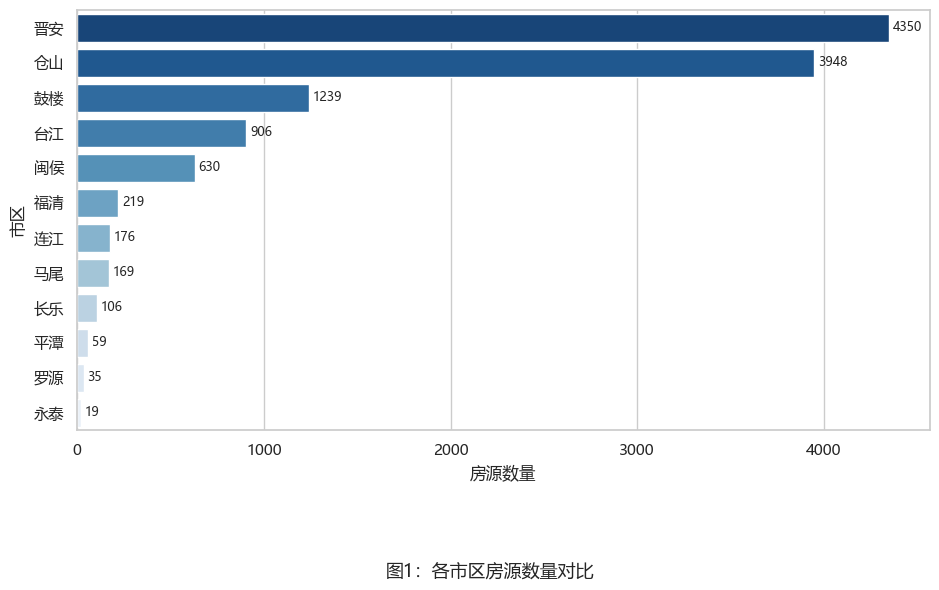

In [17]:
plt.figure(figsize=(11, 6))
district_counts = data["市区"].value_counts()
sns.barplot(x=district_counts.values, y=district_counts.index, palette="Blues_r")
plt.xlabel("房源数量")
plt.ylabel("市区")
for i, v in enumerate(district_counts.values):
    plt.text(v + 20, i, str(v), va="center", fontsize=9)
plt.figtext(0.5, -0.04, "图1：各市区房源数量对比", ha="center", va="top", fontsize=13)
plt.subplots_adjust(bottom=0.18)
plt.show()

晋安区和仓山区房源数量明显较多，是样本中的主要供应区域；鼓楼、台江等中心城区房源数量相对少，但后续价格图可以看到其价格水平并不低。

### 图表 2：不同市区均价分布差异

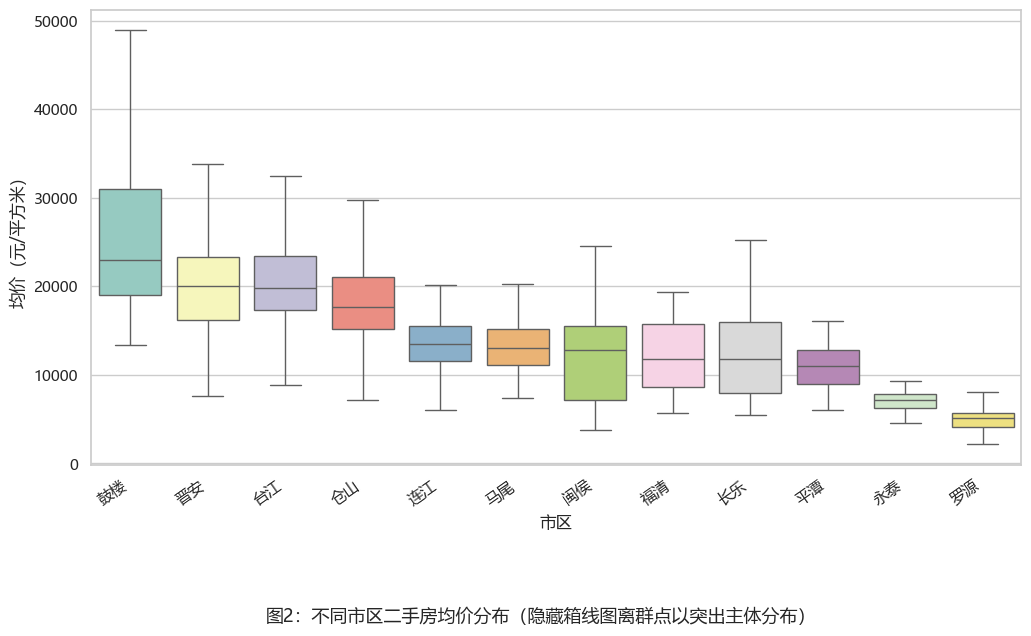

In [18]:
order_by_median_unit = price_valid.groupby("市区")["均价_元每㎡"].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6.5))
sns.boxplot(data=price_valid, x="市区", y="均价_元每㎡", order=order_by_median_unit, palette="Set3", showfliers=False)
plt.xlabel("市区")
plt.ylabel("均价（元/平方米）")
plt.xticks(rotation=35, ha="right")
plt.figtext(0.5, -0.04, "图2：不同市区二手房均价分布（隐藏箱线图离群点以突出主体分布）", ha="center", va="top", fontsize=13)
plt.subplots_adjust(bottom=0.18)
plt.show()

箱线图用于比较不同市区的价格主体分布。隐藏箱线图离群点并不是删除极端值，而是为了让各市区中位数、四分位区间更清楚。中心城区普遍表现出更高的均价中位数。

### 图表 3：面积与总价关系

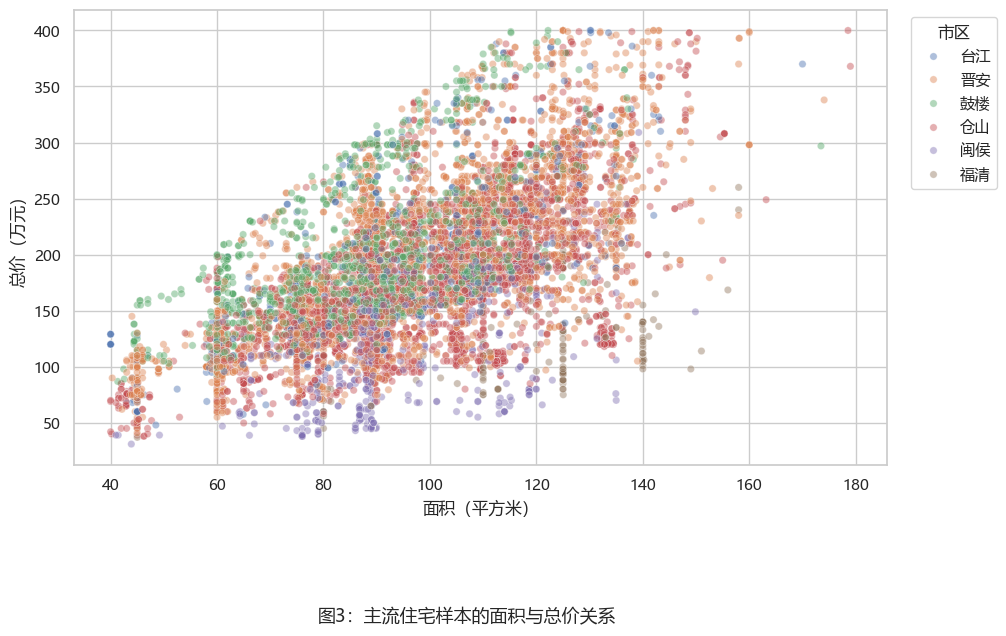

In [19]:
plt.figure(figsize=(10.5, 6.5))
top_districts = mainstream["市区"].value_counts().head(6).index
scatter_static = mainstream[mainstream["市区"].isin(top_districts)]
sns.scatterplot(
    data=scatter_static,
    x="面积_㎡",
    y="总价_万元",
    hue="市区",
    alpha=0.45,
    s=28,
)
plt.xlabel("面积（平方米）")
plt.ylabel("总价（万元）")
plt.legend(title="市区", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.figtext(0.5, -0.04, "图3：主流住宅样本的面积与总价关系", ha="center", va="top", fontsize=13)
plt.subplots_adjust(bottom=0.18)
plt.show()

面积与总价整体呈正相关，但同等面积下不同市区总价差异明显，说明地段和区域因素会显著影响总价。

### 图表 4：户型类别与总价差异

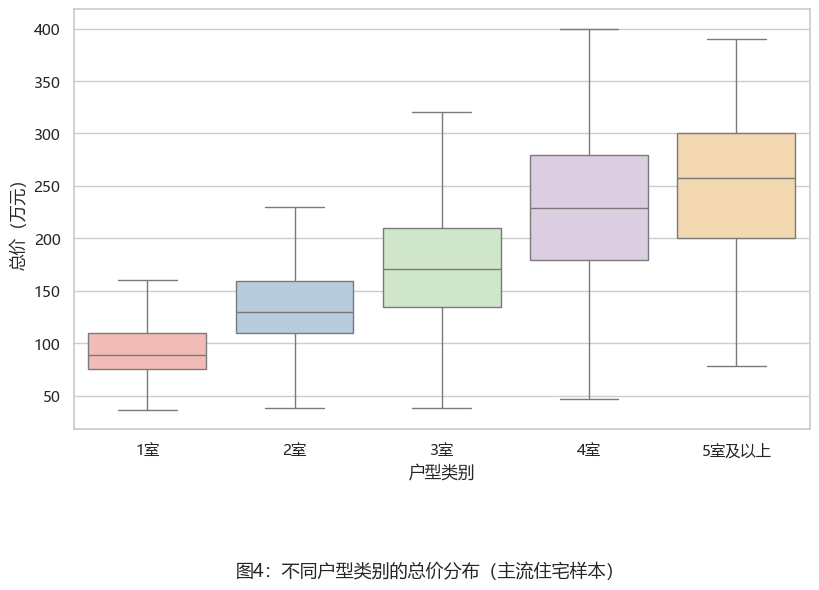

In [20]:
plt.figure(figsize=(9.5, 6))
sns.boxplot(data=mainstream, x="户型类别", y="总价_万元", palette="Pastel1", showfliers=False)
plt.xlabel("户型类别")
plt.ylabel("总价（万元）")
plt.figtext(0.5, -0.04, "图4：不同户型类别的总价分布（主流住宅样本）", ha="center", va="top", fontsize=13)
plt.subplots_adjust(bottom=0.18)
plt.show()

由图可知，户型越大，总价中位数越高。此前若把主流住宅限定为 1-4 室，会导致 `5室及以上` 没有箱型图；这里将主流住宅范围调整为 1-8 室，并用面积、总价、均价约束排除极端豪宅，因此 `5室及以上` 中仍保留普通大户型样本。

### 图表 5：房龄分类与均价差异

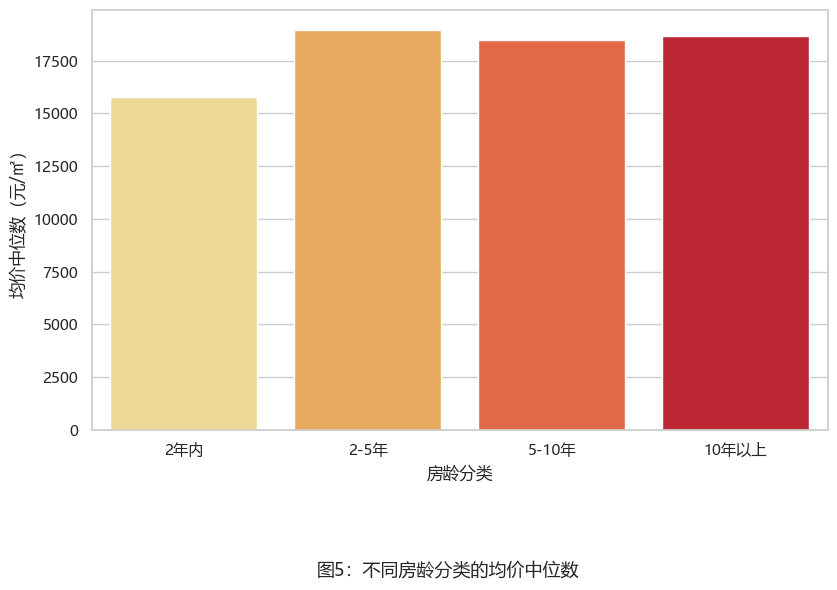

In [21]:
age_order = ["2年内", "2-5年", "5-10年", "10年以上"]
age_plot = price_valid[price_valid["房龄"].isin(age_order)].copy()

plt.figure(figsize=(9.5, 6))
sns.barplot(data=age_plot, x="房龄", y="均价_元每㎡", order=age_order, estimator=np.median, errorbar=None, palette="YlOrRd")
plt.xlabel("房龄分类")
plt.ylabel("均价中位数（元/㎡）")
plt.figtext(0.5, -0.04, "图5：不同房龄分类的均价中位数", ha="center", va="top", fontsize=13)
plt.subplots_adjust(bottom=0.18)
plt.show()

由图可知，房龄与均价并非简单线性关系。较新的房源可能有品质和配套优势，但老房源如果位于核心城区，也可能维持较高单价，需要结合区域一起判断。

### 图表 6：主要数值变量相关性热力图

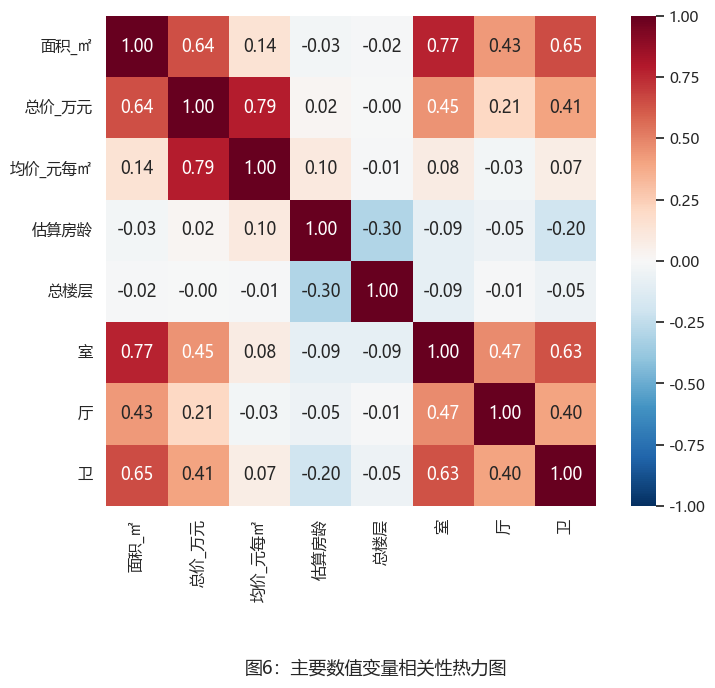

In [22]:
corr_cols = ["面积_㎡", "总价_万元", "均价_元每㎡", "估算房龄", "总楼层", "室", "厅", "卫"]
corr = price_valid[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True)
plt.figtext(0.5, -0.04, "图6：主要数值变量相关性热力图", ha="center", va="top", fontsize=13)
plt.subplots_adjust(bottom=0.18)
plt.show()

图 6 的结论需要结合变量含义谨慎解释。面积与总价的相关系数约为 0.64，说明面积越大，总价通常越高；室数、卫数与面积也有较高相关性，符合大户型通常面积更大的实际情况。均价与总价的相关系数约为 0.79，但这并不表示均价是唯一决定因素，因为总价本身约等于面积乘以均价，二者存在计算关系。相比之下，面积与均价的相关系数约为 0.14，说明大面积房源不一定单价更高，单价更多受到区位、板块、小区品质、房龄等因素影响。估算房龄与总楼层呈一定负相关，可以理解为较新的住宅往往楼层更高、电梯高层更多。

### 图表 7：交互式散点图——面积、总价、均价与市区

In [23]:
# 交互式图表用于探索具体房源。为避免 1 万多点重叠，展示时做固定随机抽样；
# 抽样只影响图表可读性，不影响前面的统计分析和结论。
plotly_scatter_df = price_valid.sample(n=min(3500, len(price_valid)), random_state=42).copy()

fig = px.scatter(
    plotly_scatter_df,
    x="面积_㎡",
    y="总价_万元",
    color="市区",
    hover_name="所属小区",
    hover_data={
        "标题": True,
        "板块": True,
        "户型": True,
        "房龄": True,
        "均价_元每㎡": ":.0f",
        "面积_㎡": ":.2f",
        "总价_万元": ":.1f",
    },
        labels={
        "面积_㎡": "面积（平方米）",
        "总价_万元": "总价（万元）",
        "均价_元每㎡": "均价（元/平方米）",
    },
    width=980,
    height=640,
)
fig.update_traces(marker=dict(size=5, opacity=0.38, line=dict(width=0)))
fig.update_layout(
    margin=dict(t=25, b=90),
    annotations=[dict(
        text="图7：交互式散点图 - 面积、总价与市区（固定随机抽样展示）",
        x=0.5, y=-0.16, xref="paper", yref="paper",
        showarrow=False, font=dict(size=16)
    )]
)
fig.show()

图 7 使用固定随机抽样展示，是因为价格非缺失样本超过 1.1 万条，如果全部绘制在交互式散点图中，点会严重重叠，既影响浏览速度，也难以看清主体分布。固定 `random_state=42` 后，每次运行抽到的样本一致，图表可复现；抽样只用于图形展示，前面的统计表、相关性分析和主要结论仍基于全量价格非缺失样本。由图可知，房源主要集中在 60-140 平方米、约 80-300 万元的主流区间，面积与总价整体呈正相关；但同等面积下，不同市区的总价差异明显，说明地段和板块对价格有重要影响。图中还可以看到少量大面积、高总价点，它们多属于别墅、豪宅或改善型房源，属于真实市场中的高端样本，而不是简单的数据错误。

### 图表 8：交互式树图——市区与板块结构

In [24]:
treemap_df = block_stats[block_stats["房源数量"] >= 20].copy()
fig2 = px.treemap(
    treemap_df,
    path=["市区", "板块"],
    values="房源数量",
    color="均价中位数_元每㎡",
    color_continuous_scale="RdYlBu_r",
    hover_data={"房源数量": True, "均价中位数_元每㎡": ":.0f", "总价中位数_万元": ":.1f"},
        width=980,
    height=650,
)
fig2.update_layout(
    margin=dict(t=25, b=90),
    annotations=[dict(
        text="图8：交互式树图 - 市区与板块房源结构及均价",
        x=0.5, y=-0.12, xref="paper", yref="paper",
        showarrow=False, font=dict(size=16)
    )]
)
fig2.show()

树图同时展示房源数量和板块均价。面积越大代表房源数量越多，颜色越偏红代表均价中位数越高，有助于快速识别高价板块和供应集中板块。

## 8. 主要结论

下面的结论由前面的统计表和图表支持。

1. 从房源供应看，晋安区的房源数量最多，价格非缺失样本中共有 4346 条；仓山区其次，共 3926 条。这说明本数据中的福州二手房供给主要集中在晋安和仓山两个区域。
2. 从均价中位数看，鼓楼区价格水平最高，约为 22973 元/平方米；罗源县约为 5103 元/平方米，处于较低水平。中心城区和外围县市之间存在明显价格梯度。
3. 户型结构以 3 室房源为主，共 7183 条，中位总价约 175 万元。三房更接近家庭居住需求，是样本中的主流产品。
4. 面积与总价的相关系数约为 0.64，说明面积越大通常总价越高；均价与总价相关系数约为 0.79，但这与“总价约等于面积 × 均价”的计算关系有关，不能简单理解为均价单独决定总价。面积与均价相关系数约为 0.14，说明单价更多受到区位、板块、小区品质、房龄等因素影响。
5. 房龄与价格不能简单理解为“越新越贵”或“越老越便宜”。较新房源可能有品质优势，但核心城区老房源也可能因地段和配套保持较高单价。
6. 在样本数不少于 30 的板块中，鼓楼五四路板块均价中位数约 31936 元/平方米，样本数为 49 条，说明核心板块具有明显价格优势。
7. 标题中包含“学区”相关词的房源均价中位数约 20741 元/平方米，比不含该关键词的房源高约 2431 元/平方米。教育资源可能是影响房源挂牌价的重要卖点之一。
8. 高总价、高均价、大面积样本多数属于真实豪宅、别墅或改善型房源，不应简单作为错误值删除。本报告保留全量样本，同时使用主流住宅子集辅助观察普通二手房市场。
9. 总价和均价缺失的 26 条样本没有进行填充，因为价格是核心变量，填充会扭曲价格分布；这些样本仅在价格相关分析中排除。

## 9. 不足与改进方向

本数据来自房源列表，能够反映挂牌房源特征，但仍有局限：

- 挂牌价不等于最终成交价，不能完全代表真实成交市场。
- 数据没有经纬度、地铁距离、学区等级、装修标准等更细变量，因此只能通过标题关键词做近似分析。
- 同一小区可能存在多个相似房源，关键字段近似重复不一定代表完全重复，需要结合链接和详情页进一步确认。
- 后续如能补充成交数据、地图距离和小区配套信息，可进一步分析地段溢价和交通配套对价格的影响。